In [2]:
# import pandas for working with tabular data
import pandas as pd 

# load the csv file into a dataframe
df = pd.read_csv("DataAnalyst.csv") 

#look at first 5 rows
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [3]:
# check column types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   str    
 2   Salary Estimate    2253 non-null   str    
 3   Job Description    2253 non-null   str    
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   str    
 6   Location           2253 non-null   str    
 7   Headquarters       2253 non-null   str    
 8   Size               2253 non-null   str    
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   str    
 11  Industry           2253 non-null   str    
 12  Sector             2253 non-null   str    
 13  Revenue            2253 non-null   str    
 14  Competitors        2253 non-null   str    
 15  Easy Apply         2253 non-null   str    
dtypes: float64(1), int64(2), str(13)
me

In [4]:
# check number of rows and columns
df.shape

(2253, 16)

In [5]:
# drop extra index column
df = df.drop("Unnamed: 0", axis = 1)
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [6]:
# count missing values per column
df.isnull().sum()

Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         1
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64

In [7]:
# check for placeholder values like -1 or "Unknown" that might represent missing data
print(df["Rating"].value_counts().head())

print(df["Competitors"].value_counts().head())

print(df["Easy Apply"].value_counts().head())

print(df["Founded"].value_counts().head())

Rating
-1.0    272
 3.9    140
 3.6    135
 3.7    132
 5.0    131
Name: count, dtype: int64
Competitors
-1                                                      1732
Adecco, Manpower                                          14
Robert Half, Insight Global                               14
Artech Information Systems, Mindlance, Tech Mahindra      10
TEKsystems, Insight Global, Accenture                     10
Name: count, dtype: int64
Easy Apply
-1      2173
True      80
Name: count, dtype: int64
Founded
-1       660
 2008     80
 2002     54
 1996     54
 2000     54
Name: count, dtype: int64


In [8]:
# Glassdoor dataset uses -1 as a placeholder for missing values instead of leaving the cell empty this means pandas doesn't recognize them as missing by default

# So we replace -1 with pd.NA and so pandas reads them as real missing values
df["Rating"] = df["Rating"].replace(-1, pd.NA)

df["Founded"] = df["Founded"].replace(-1, pd.NA)

df["Competitors"] = df["Competitors"].replace("-1", pd.NA)

df["Easy Apply"] = df["Easy Apply"].replace("-1", pd.NA)

In [9]:
df.isnull().sum()

Job Title               0
Salary Estimate         0
Job Description         0
Rating                272
Company Name            1
Location                0
Headquarters            0
Size                    0
Founded               660
Type of ownership       0
Industry                0
Sector                  0
Revenue                 0
Competitors          1732
Easy Apply           2173
dtype: int64

In [10]:
# Company Name has rating stuck to it after a newline
# so we split on "\n" and keep only the first part (the actual name) 
df["Company Name"] = df["Company Name"].str.split("\n").str[0]
df["Company Name"].head()

0             Vera Institute of Justice
1    Visiting Nurse Service of New York
2                           Squarespace
3                              Celerity
4                               FanDuel
Name: Company Name, dtype: object

In [11]:
# we drop Competitors column insted of keeping it unused
df = df.drop("Competitors", axis = 1)
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Easy Apply'],
      dtype='str')

In [12]:
# clean the salary text
salary_clean = df["Salary Estimate"].str.replace("(Glassdoor est.)", "", regex = False)
salary_clean = salary_clean.str.replace("$", "", regex = False)
salary_clean = salary_clean.str.replace("K", "", regex = False)


In [13]:
# split into low and high salary, convert to numbers
df["Salary Min"] = pd.to_numeric(salary_clean.str.split("-").str[0])
df["Salary Max"] = pd.to_numeric(salary_clean.str.split("-").str[1])
df[["Salary Estimate", "Salary Min", "Salary Max"]].head()

,Salary Estimate,Salary Min,Salary Max
0,$37K-$66K (Glassdoor est.),37.0,66
1,$37K-$66K (Glassdoor est.),37.0,66
2,$37K-$66K (Glassdoor est.),37.0,66
3,$37K-$66K (Glassdoor est.),37.0,66
4,$37K-$66K (Glassdoor est.),37.0,66


In [14]:
df["Salary Estimate"].unique()

<StringArray>
[  '$37K-$66K (Glassdoor est.)',   '$46K-$87K (Glassdoor est.)',
   '$51K-$88K (Glassdoor est.)',   '$51K-$87K (Glassdoor est.)',
   '$59K-$85K (Glassdoor est.)',   '$43K-$76K (Glassdoor est.)',
  '$60K-$110K (Glassdoor est.)',   '$41K-$78K (Glassdoor est.)',
   '$45K-$88K (Glassdoor est.)',  '$73K-$127K (Glassdoor est.)',
   '$84K-$90K (Glassdoor est.)',   '$27K-$52K (Glassdoor est.)',
   '$42K-$74K (Glassdoor est.)',  '$77K-$132K (Glassdoor est.)',
  '$98K-$114K (Glassdoor est.)',   '$48K-$96K (Glassdoor est.)',
   '$26K-$47K (Glassdoor est.)',   '$31K-$59K (Glassdoor est.)',
   '$47K-$81K (Glassdoor est.)',   '$43K-$69K (Glassdoor est.)',
  '$49K-$112K (Glassdoor est.)',   '$30K-$54K (Glassdoor est.)',
  '$55K-$103K (Glassdoor est.)',   '$37K-$70K (Glassdoor est.)',
  '$57K-$103K (Glassdoor est.)',   '$35K-$45K (Glassdoor est.)',
   '$42K-$66K (Glassdoor est.)',   '$65K-$81K (Glassdoor est.)',
 '$113K-$132K (Glassdoor est.)',   '$42K-$63K (Glassdoor est.)',
   '$60K-$6

In [ ]:
# creat an average salary column to make analysis easier
df["Salary Avg"] = (df["Salary Min"] + df["Salary Max"])/2
df[["Salary Min", "Salary Max", "Salary Avg"]].head()

,Salary Min,Salary Max,Salary Avg
0,37.0,66,51.5
1,37.0,66,51.5
2,37.0,66,51.5
3,37.0,66,51.5
4,37.0,66,51.5


In [ ]:
# group jobs by indusrtry and calculate the average salary for each and sort values 
avg_salary_by_industry = df.groupby("Industry")["Salary Avg"].mean().sort_values(ascending = False)
avg_salary_by_industry.head(10)


Industry
Drug & Health Stores                      95.250000
Education Training Services               92.833333
Health Care Products Manufacturing        89.800000
Sports & Recreation                       88.166667
Gambling                                  88.000000
News Outlet                               87.000000
Transportation Equipment Manufacturing    85.000000
Electrical & Electronic Manufacturing     84.666667
Utilities                                 83.250000
Biotech & Pharmaceuticals                 83.106061
Name: Salary Avg, dtype: float64

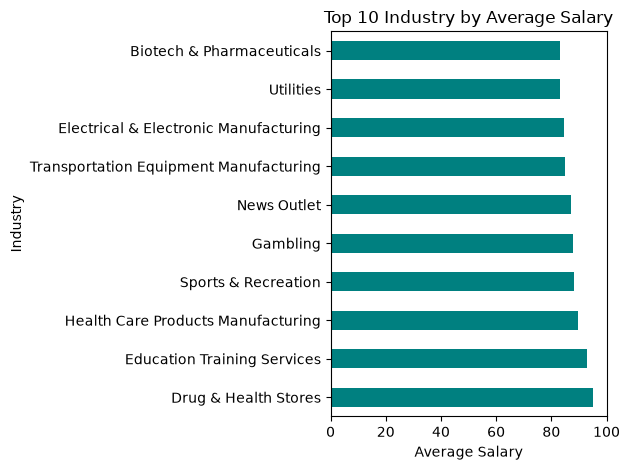

In [18]:
import matplotlib.pyplot as plt

# plot the top 10 highest paying industries as a horizontal bar chart

avg_salary_by_industry.head(10).plot(kind = "barh", color = "teal")

plt.title("Top 10 Industry by Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()